In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 실습1
df = pd.read_csv('22_equipment_sensor.csv')

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.set_index("timestamp").sort_index()

one_min = df[["vibration", "temperature"]].resample("1min").mean()

print(one_min['vibration'].head(3).round(2))
print(one_min['vibration'].isna().sum())

timestamp
2024-03-01 09:00:00    0.39
2024-03-01 09:01:00    0.41
2024-03-01 09:02:00    0.44
Freq: min, Name: vibration, dtype: float64
1


In [ ]:
print(df['temp_core'].resample('D').max().head(1))

In [10]:
sec = df.index.to_series().diff().dt.total_seconds()
print(sec.value_counts().sort_index().head())

timestamp
3.0       1
5.0       2
7.0       3
9.0       1
10.0    169
Name: count, dtype: int64


In [11]:
#실습2
df = pd.read_csv('22_equipment_sensor.csv')
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp").sort_index()

gaps = df.index.to_series().diff().dt.total_seconds()

print('간격별 빈도:', gaps.value_counts().sort_index())
print(f'가장 크게 벌어진 측정 간격: {gaps.max()}')

간격별 빈도: timestamp
3.0       1
5.0       2
7.0       3
9.0       1
10.0    169
12.0      1
13.0      1
14.0      1
17.0      1
20.0      5
21.0      1
80.0      1
Name: count, dtype: int64
가장 크게 벌어진 측정 간격: 80.0


In [12]:
# asferq

result = df[['vibration']].asfreq('10s')

print('총 행:', len(result))
print(result['vibration'].isna().sum())

총 행: 200
22


In [13]:
a = df[['vibration']].asfreq('10s')

print(a['vibration'].isna().sum())

b = df[['vibration']].asfreq('10s', method='ffill')
print(b['vibration'].isna().sum())

22
0


In [14]:
# 실습3

cols = ['vibration', 'temperature']

norm = df[cols].asfreq('10s')

print(f'총 행 수: {len(norm)}, 열별 결측 개수: {norm.isna().sum()}')
filled = df[cols].asfreq('10s', method='ffill')
print(f'ffill 이후:{filled.isna().sum()}')

총 행 수: 200, 열별 결측 개수: vibration      22
temperature    22
dtype: int64
ffill 이후:vibration      0
temperature    0
dtype: int64


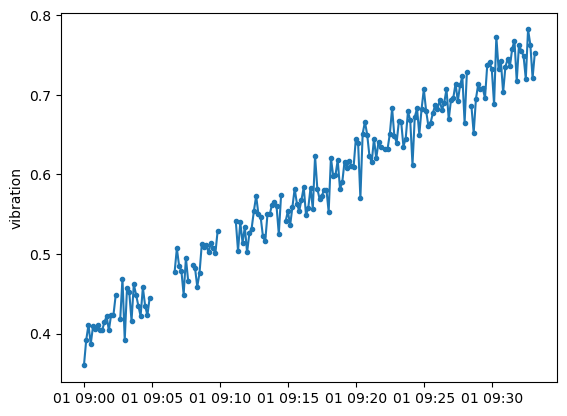

In [16]:
norm = df[['vibration']].asfreq('10s')

plt.plot(norm.index, norm['vibration'], marker='.')
plt.ylabel('vibration')
plt.show()

In [ ]:
# 실습4

norm = df[['vibration', 'temperature']].asfreq('10s')
print('결측 개수:', norm.isna().sum()) 
print('결측 비율(%):',norm.isna().mean()*100)

miss = norm[norm["vibration"].isna()].index

print("miss 개수:", len(miss))
print("첫 번째 시각:", miss[0])

결측 개수: vibration      22
temperature    22
dtype: int64
결측 비율: vibration      11.0
temperature    11.0
dtype: float64 %
miss 개수: 22
첫 번째 시각: 2024-03-01 09:02:30


In [34]:
df = pd.read_csv('22_열처리.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

lin = df['제어출력'].interpolate(method='linear')

time = df['제어출력'].interpolate(method='time')

print('linear interpolation:')
print(lin.head())
print('time interpolation:')
print(time.head())

linear interpolation:
timestamp
2024-03-01 09:00:00    0.426
2024-03-01 09:00:10    0.463
2024-03-01 09:00:20    0.438
2024-03-01 09:00:30    0.445
2024-03-01 09:00:40    0.421
Name: 제어출력, dtype: float64
time interpolation:
timestamp
2024-03-01 09:00:00    0.426
2024-03-01 09:00:10    0.463
2024-03-01 09:00:20    0.438
2024-03-01 09:00:30    0.445
2024-03-01 09:00:40    0.421
Name: 제어출력, dtype: float64


In [ ]:
#실습2

s = pd.Series([10.0, np.nan, 40.0], index=pd.to_datetime(['09:00:00', '09:00:10', '09:01:00']))

print('linear interpolation:', s.interpolate(method='linear').iloc[1])
print('time interpolation', s.interpolate(method='time').iloc[1])


lin = df['제어출력'].interpolate()
time = df['제어출력'].interpolate(method='time')

print('서로 다른 칸 수:', int((lin != time).sum()))

linear interpolation: 25.0
time interpolation 15.0
서로 다른 칸 수: 0


C:\Users\user\AppData\Local\Temp\ipykernel_31292\100714164.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  s = pd.Series([10.0, np.nan, 40.0], index=pd.to_datetime(['09:00:00', '09:00:10', '09:01:00']))
